# Joukowski transformation

The **Joukowski transformation** turns a circle in the complex $z$-plane into an airfoil-like curve in the complex $\xi$-plane. This notebook makes the mapping visible by following the same labelled points $P_0,P_1,\ldots$ before and after the transformation.

> The colours and labels are identities: a blue $P_3$ in the $z$-plane is the very same point after it appears in the $\xi$-plane.

## 💙 1. The transformation

For a non-zero complex number $z=x+iy$, the Joukowski map is

$$
\boxed{\;\xi = J(z)=z+\frac{a^2}{z}\;}
$$

where $a>0$ controls the scale. Writing $\xi=u+iv$, every point $(x,y)$ in the first plane obtains a new position $(u,v)$ in the second plane.

We use a circle whose centre is slightly left of and above the origin. The circle passes through $z=a$, where

$$
J'(z)=1-\frac{a^2}{z^2}=0.
$$

That critical point becomes the sharp **trailing edge** of the airfoil. The circle must not pass through $z=0$, because the transformation is undefined there.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import patheffects
from matplotlib.colors import LinearSegmentedColormap

plt.rcParams.update({
    "figure.dpi": 140,
    "font.family": "DejaVu Sans",
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.labelsize": 11,
})

# A luminous palette designed for the dark visualisation panels.
BG = "#07111F"
PANEL = "#0E1C2F"
PANEL_EDGE = "#29435F"
TEXT = "#EAF6FF"
MUTED = "#9DB2C8"
GRID = "#7DD3FC"

point_cmap = LinearSegmentedColormap.from_list(
    "joukowski_points", ["#38BDF8", "#22D3EE", "#34D399", "#FBBF24", "#FB7185", "#C084FC"]
)

In [2]:
def joukowski(z, a=1.0):
    """Map non-zero complex coordinates z to xi = z + a²/z."""
    return z + a**2 / z


a = 1.0
centre = -0.12 + 0.10j
radius = abs(a - centre)  # makes the circle pass through z = a

# Start at the trailing-edge point and travel counter-clockwise.
theta_trailing = np.angle(a - centre)
theta = theta_trailing + np.linspace(0, 2 * np.pi, 1200, endpoint=True)
z_curve = centre + radius * np.exp(1j * theta)
xi_curve = joukowski(z_curve, a)

n_points = 12
theta_points = theta_trailing + np.linspace(0, 2 * np.pi, n_points, endpoint=False)
z_points = centre + radius * np.exp(1j * theta_points)
xi_points = joukowski(z_points, a)
labels = [f"P{k}" for k in range(n_points)]
colours = point_cmap(np.linspace(0, 1, n_points, endpoint=False))

## 💙 2. The same points in two planes

The left panel is the input geometry. The right panel is its image under $J$. Compare labels—not just locations—to track the mapping.

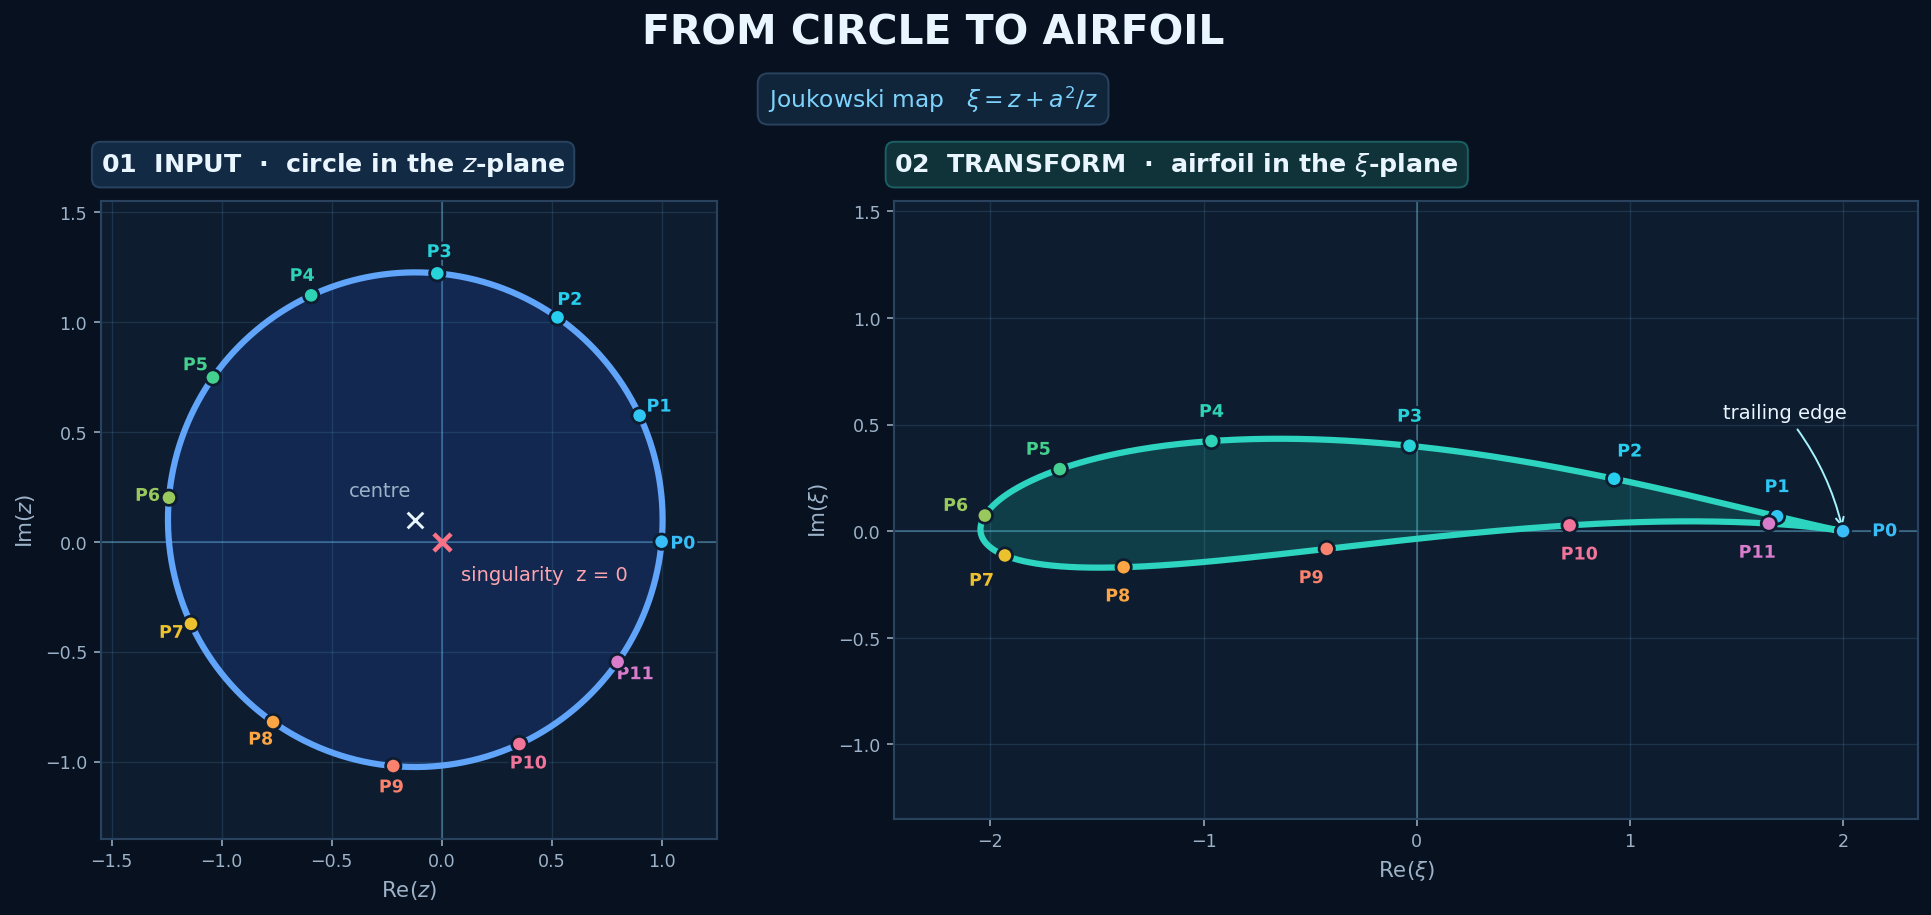

In [3]:
fig, axes = plt.subplots(
    1, 2, figsize=(14.5, 6.7),
    gridspec_kw={"width_ratios": [1, 1.35]},
)
fig.patch.set_facecolor(BG)

for ax in axes:
    ax.set_facecolor(PANEL)
    ax.axhline(0, color=GRID, lw=1, alpha=0.35, zorder=0)
    ax.axvline(0, color=GRID, lw=1, alpha=0.35, zorder=0)
    ax.grid(color=GRID, lw=0.7, alpha=0.13)
    ax.set_aspect("equal", adjustable="box")
    ax.set_anchor("N")
    ax.tick_params(colors=MUTED, labelsize=9)
    ax.xaxis.label.set_color(MUTED)
    ax.yaxis.label.set_color(MUTED)
    for spine in ax.spines.values():
        spine.set_color(PANEL_EDGE)
        spine.set_linewidth(1.1)

# z-plane
axes[0].fill(z_curve.real, z_curve.imag, color="#2563EB", alpha=0.18)
axes[0].plot(z_curve.real, z_curve.imag, color="#60A5FA", lw=3.2, solid_capstyle="round")
axes[0].scatter(z_points.real, z_points.imag, c=colours, s=62, edgecolor=PANEL, linewidth=1.4, zorder=4)
axes[0].scatter([centre.real], [centre.imag], marker="x", s=65, color=TEXT, zorder=5)
axes[0].scatter([0], [0], marker="x", s=78, color="#FB7185", linewidth=2.3, zorder=5)
axes[0].annotate("centre", (centre.real, centre.imag), xytext=(-34, 12), textcoords="offset points", color=MUTED)
axes[0].annotate("singularity  z = 0", (0, 0), xytext=(10, -20), textcoords="offset points", color="#FDA4AF")
axes[0].set_title(r"01  INPUT  ·  circle in the $z$-plane", loc="left", pad=15, color=TEXT, fontsize=13, bbox={"boxstyle": "round,pad=0.35", "facecolor": "#132A44", "edgecolor": PANEL_EDGE})
axes[0].set_xlabel(r"$\operatorname{Re}(z)$")
axes[0].set_ylabel(r"$\operatorname{Im}(z)$")
axes[0].set_xlim(-1.55, 1.25)
axes[0].set_ylim(-1.35, 1.55)

# xi-plane
axes[1].fill(xi_curve.real, xi_curve.imag, color="#14B8A6", alpha=0.22)
axes[1].plot(xi_curve.real, xi_curve.imag, color="#2DD4BF", lw=3.2, solid_capstyle="round")
axes[1].scatter(xi_points.real, xi_points.imag, c=colours, s=62, edgecolor=PANEL, linewidth=1.4, zorder=4)
axes[1].annotate("trailing edge", (xi_points[0].real, xi_points[0].imag), xytext=(-30, 58), textcoords="offset points", ha="center", arrowprops={"arrowstyle": "->", "color": "#A5F3FC", "connectionstyle": "arc3,rad=-0.12"}, color=TEXT)
axes[1].set_title(r"02  TRANSFORM  ·  airfoil in the $\xi$-plane", loc="left", pad=15, color=TEXT, fontsize=13, bbox={"boxstyle": "round,pad=0.35", "facecolor": "#10333A", "edgecolor": "#1B5F63"})
axes[1].set_xlabel(r"$\operatorname{Re}(\xi)$")
axes[1].set_ylabel(r"$\operatorname{Im}(\xi)$")
axes[1].set_xlim(-2.45, 2.35)
axes[1].set_ylim(-1.35, 1.55)

# Labels use an outward offset in each geometry. The transformed points
# crowd together near the trailing edge, so explicit offsets keep every
# label readable while preserving its point colour.
xi_label_offsets = {
    0: (15, 0), 1: (0, 15), 2: (8, 14), 3: (0, 15),
    4: (0, 15), 5: (-11, 10), 6: (-15, 5), 7: (-12, -13),
    8: (-3, -15), 9: (-8, -15), 10: (5, -15), 11: (-6, -15),
}

for k, (z, xi, colour) in enumerate(zip(z_points, xi_points, colours)):
    z_direction = (z - centre) / abs(z - centre)
    axes[0].annotate(labels[k], (z.real, z.imag), xytext=(11*z_direction.real, 11*z_direction.imag), textcoords="offset points", ha="center", va="center", fontsize=9, weight="bold", color=colour, path_effects=[patheffects.withStroke(linewidth=2.8, foreground=PANEL)])

    label_ha = "left" if k == 0 else "center"
    axes[1].annotate(labels[k], (xi.real, xi.imag), xytext=xi_label_offsets[k], textcoords="offset points", ha=label_ha, va="center", fontsize=9, weight="bold", color=colour, path_effects=[patheffects.withStroke(linewidth=2.8, foreground=PANEL)])

fig.subplots_adjust(left=0.055, right=0.985, bottom=0.10, top=0.78, wspace=0.12)
fig.suptitle("FROM CIRCLE TO AIRFOIL", y=0.98, fontsize=21, weight="bold", color=TEXT)
fig.text(0.5, 0.88, r"Joukowski map   $\xi=z+a^2/z$", ha="center", color="#7DD3FC", fontsize=12, bbox={"boxstyle": "round,pad=0.45", "facecolor": "#10243A", "edgecolor": PANEL_EDGE})
plt.show()

### What should we notice?

- $P_0$ begins at $z=a$ and maps to $\xi=2a$. It becomes the sharp trailing edge.
- Points that are nearly evenly spaced on the circle are **not** evenly spaced after the map. The transformation stretches some regions and compresses others.
- The offset centre makes the upper and lower surfaces asymmetric, producing camber.
- The order of the labels is preserved as we travel around the boundary.

## 💙 3. Visualising the movement

The Joukowski map sends each point directly from $z$ to $\xi$. To make that change easier to see, the next figure adds illustrative in-between frames

$$
q_t=(1-t)z+tJ(z), \qquad 0\leq t\leq 1.
$$

These intermediate curves are a visual interpolation, not additional Joukowski transformations.

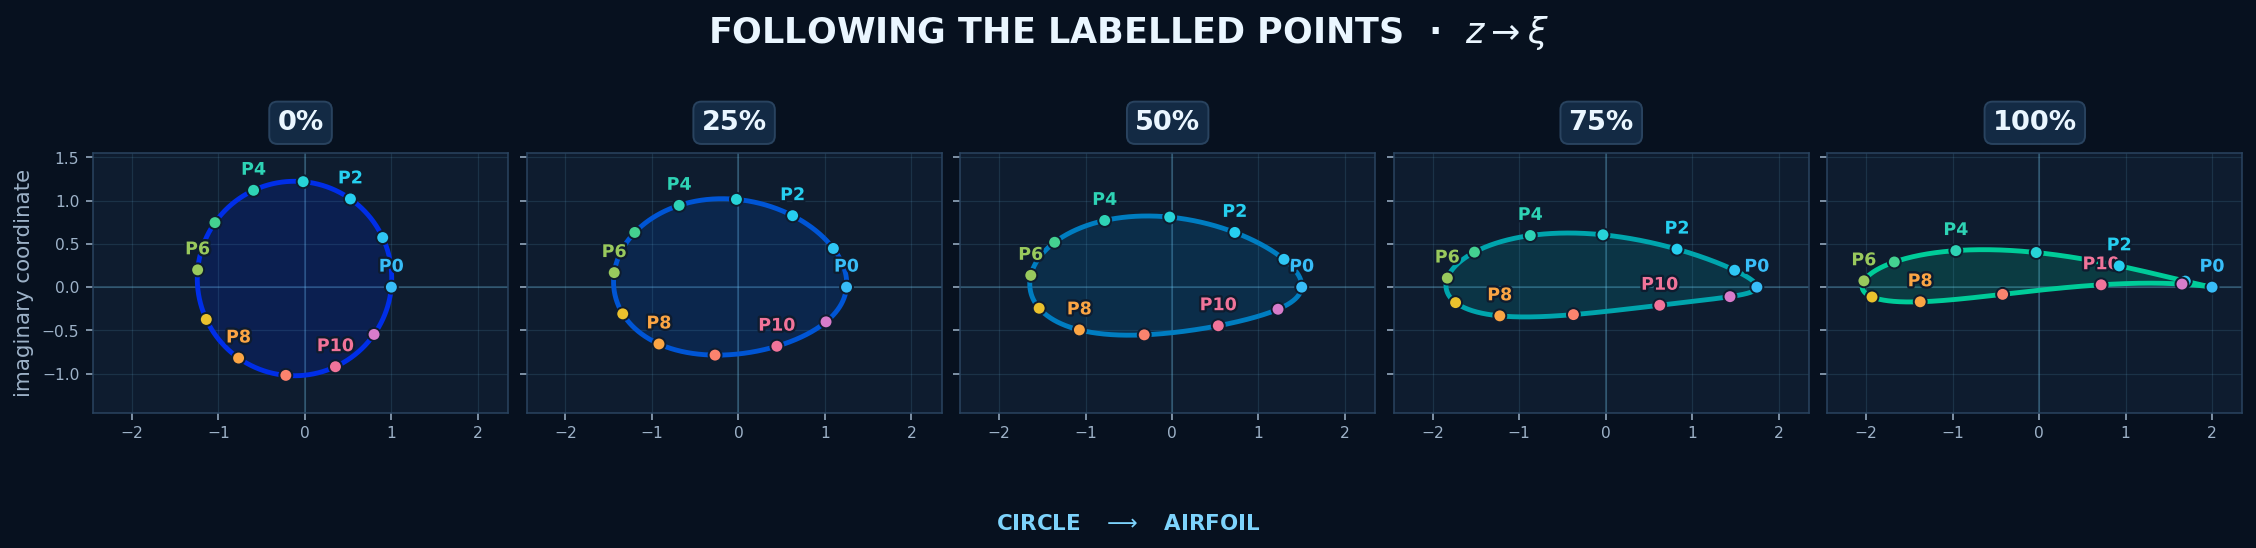

In [4]:
stages = np.linspace(0, 1, 5)
fig, axes = plt.subplots(1, 5, figsize=(16, 3.8), sharex=True, sharey=True, constrained_layout=True)
fig.patch.set_facecolor(BG)

for ax, t in zip(axes, stages):
    curve_t = (1 - t) * z_curve + t * xi_curve
    points_t = (1 - t) * z_points + t * xi_points

    ax.set_facecolor(PANEL)
    stage_colour = plt.cm.winter(0.18 + 0.62 * t)
    ax.fill(curve_t.real, curve_t.imag, color=stage_colour, alpha=0.18)
    ax.plot(curve_t.real, curve_t.imag, color=stage_colour, lw=2.5, solid_capstyle="round")
    ax.scatter(points_t.real, points_t.imag, c=colours, s=44, edgecolor=PANEL, linewidth=1.0, zorder=4)

    for k, point in enumerate(points_t):
        if k % 2 == 0:  # label alternate points to keep the small panels clear
            ax.annotate(labels[k], (point.real, point.imag), xytext=(0, 8), textcoords="offset points", ha="center", fontsize=9, weight="bold", color=colours[k], path_effects=[patheffects.withStroke(linewidth=2.4, foreground=PANEL)])

    ax.axhline(0, color=GRID, lw=0.8, alpha=0.3, zorder=0)
    ax.axvline(0, color=GRID, lw=0.8, alpha=0.3, zorder=0)
    ax.grid(color=GRID, lw=0.6, alpha=0.12)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(-2.45, 2.35)
    ax.set_ylim(-1.45, 1.55)
    ax.set_title(f"{t:.0%}", color=TEXT, pad=12, bbox={"boxstyle": "round,pad=0.3", "facecolor": "#132A44", "edgecolor": PANEL_EDGE})
    ax.tick_params(colors=MUTED, labelsize=8)
    for spine in ax.spines.values():
        spine.set_color(PANEL_EDGE)

axes[0].set_ylabel("imaginary coordinate", color=MUTED)
fig.supxlabel(r"CIRCLE   $\longrightarrow$   AIRFOIL", fontsize=11, weight="bold", color="#7DD3FC")
fig.suptitle(r"FOLLOWING THE LABELLED POINTS  ·  $z \rightarrow \xi$", fontsize=18, weight="bold", color=TEXT)
plt.show()

## 💙 4. Numerical coordinates

A few coordinates confirm exactly what the pictures show.

In [5]:
import pandas as pd

coordinate_table = pd.DataFrame({
    "point": labels,
    "Re(z)": z_points.real,
    "Im(z)": z_points.imag,
    "Re(xi)": xi_points.real,
    "Im(xi)": xi_points.imag,
}).round(3)
coordinate_table

,point,Re(z),Im(z),Re(xi),Im(xi)
0,P0,1.000,0.000,2.000,0.000
1,P1,0.900,0.573,1.690,0.070
2,P2,0.527,1.020,0.926,0.246
3,P3,-0.020,1.220,-0.033,0.401
4,P4,-0.593,1.120,-0.963,0.423
5,P5,-1.040,0.747,-1.674,0.291
6,P6,-1.240,0.200,-2.026,0.073
7,P7,-1.140,-0.373,-1.932,-0.114
8,P8,-0.767,-0.820,-1.375,-0.169
9,P9,-0.220,-1.020,-0.422,-0.083


## Summary

The Joukowski transformation is a compact example of how a simple formula in complex analysis can create useful geometry. By keeping each $P_k$ label and colour unchanged, we can see that the airfoil is not a newly drawn object: it is the original circle, point by point, after the map $J(z)=z+a^2/z$.